# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 4**. Fill in every member before submitting.

1. Full name: Saty Viard  Student ID: B00822312
2. Full name: Pollux Gronier  Student ID: B00822392
3. Full name: Eliott Beghin  Student ID: B00824999
4. Full name: —  Student ID: —

**Group / repo name:** `aidams-lab2-viard-gronier-beghin`  
**Submitter (one person):** Pollux Gronier (B00822392)  
**Repo URL:** https://github.com/Polluxgnr/lab2  


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [1]:
# Task 1.1 – Load and Inspect Data
import os
import warnings
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Clean warning output for presentation
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="pandera")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 10

excel_file = "Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"

# 1. Load primary sheets via Pandas
print("Loading primary sheets via Pandas...")
df_meta = pd.read_excel(excel_file, sheet_name="Plant data")
df_cap_raw = pd.read_excel(excel_file, sheet_name="Plant capacities and status")
df_prod_raw = pd.read_excel(excel_file, sheet_name="Plant production")

# Bonus: Polars loading demonstration
print("Bonus: Demonstrating Polars loading...")
pl_plant_meta = pl.read_excel(excel_file, sheet_name="Plant data")
print(f"-> [Polars] Loaded {pl_plant_meta.shape[0]} rows, {pl_plant_meta.shape[1]} columns successfully.")

# 2. Extract Crude Steel Production (Target Variable)
# Take the most recent reported verified annual production: 2023 -> 2022 -> 2024 -> 2021
crude_prod = df_prod_raw[df_prod_raw["Type of production"] == "Crude steel production (ttpa)"].copy()
for y in [2019, 2020, 2021, 2022, 2023, 2024]:
    crude_prod[y] = pd.to_numeric(crude_prod[y], errors="coerce")

crude_prod["production"] = crude_prod[2023].fillna(crude_prod[2022]).fillna(crude_prod[2024]).fillna(crude_prod[2021])
target_df = crude_prod.groupby("GEM plant ID")["production"].first().reset_index()

# 3. Process Capacities at Plant Level
# In GEM, '>0' means an operating unit exists, but exact capacity is unconfirmed.
# We map '>0' to NaN so it is handled as missing data (for median imputation) rather than false 0.
cap_cols = [
    "Nominal crude steel capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal iron capacity (ttpa)"
]

df_cap_proc = df_cap_raw.copy()
for col in cap_cols:
    df_cap_proc[col] = pd.to_numeric(df_cap_proc[col].replace(">0", np.nan), errors="coerce")

# Sum capacities across units per plant (min_count=1 ensures plants where all units are NaN remain NaN)
cap_agg = df_cap_proc.groupby("GEM plant ID")[cap_cols].sum(min_count=1).reset_index()
status_agg = df_cap_raw.groupby("GEM plant ID")["Status"].first().reset_index()
equip_agg = df_cap_raw.groupby("GEM plant ID")["Main production equipment"].first().reset_index()

# 4. Merge into unified 1-row-per-plant DataFrame
df_plants = target_df.merge(cap_agg, on="GEM plant ID", how="left")
df_plants = df_plants.merge(status_agg, on="GEM plant ID", how="left")
df_plants = df_plants.merge(equip_agg, on="GEM plant ID", how="left")
df_plants = df_plants.merge(
    df_meta[["GEM plant ID", "Plant name (English)", "Country/area", "Region", "Workforce size", "Plant age", "SOE status"]],
    on="GEM plant ID",
    how="left"
)

print("\n" + "="*50)
print(f"Plant-Level Dataset Shape: {df_plants.shape[0]} rows (plants), {df_plants.shape[1]} columns")
print("="*50)
print("\nColumn Data Types and Missing Values:")
info_df = pd.DataFrame({
    "Dtype": df_plants.dtypes,
    "Non-Null Count": df_plants.notnull().sum(),
    "Missing Count": df_plants.isnull().sum(),
    "Missing Pct (%)": (df_plants.isnull().sum() / len(df_plants) * 100).round(1)
})
display(info_df)

print(f"\nTarget Variable: 'production' ({df_plants['production'].notna().sum()} plants with verified production)")
print("Key Predictors: Nominal crude steel capacity, sub-capacities (BOF, EAF, Iron), Main equipment, Status, Workforce, Plant age.")
display(df_plants.head(5))


Loading primary sheets via Pandas...


Bonus: Demonstrating Polars loading...
-> [Polars] Loaded 1293 rows, 44 columns successfully.



Plant-Level Dataset Shape: 424 rows (plants), 14 columns

Column Data Types and Missing Values:


,Dtype,Non-Null Count,Missing Count,Missing Pct (%)
GEM plant ID,object,424,0,0.0
production,float64,374,50,11.8
Nominal crude steel capacity (ttpa),float64,424,0,0.0
Nominal BOF steel capacity (ttpa),float64,192,232,54.7
Nominal EAF steel capacity (ttpa),float64,307,117,27.6
Nominal iron capacity (ttpa),float64,238,186,43.9
Status,object,424,0,0.0
Main production equipment,object,424,0,0.0
Plant name (English),object,424,0,0.0
Country/area,object,424,0,0.0



Target Variable: 'production' (374 plants with verified production)
Key Predictors: Nominal crude steel capacity, sub-capacities (BOF, EAF, Iron), Main equipment, Status, Workforce, Plant age.


,GEM plant ID,production,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal iron capacity (ttpa),Status,Main production equipment,Plant name (English),Country/area,Region,Workforce size,Plant age,SOE status
0,P100000120001,3237.0,3500.0,NaN,3500.0,4200.0,operating,DRI; EAF,Emsteel Abu Dhabi steel plant,United Arab Emirates,Middle East,3703,23,Partial
1,P100000120006,1100.0,2000.0,NaN,2000.0,600.0,operating,DRI; EAF,ArcelorMittal Acindar Villa Constitución steel...,Argentina,Central & South America,1594,80,NaN
2,P100000120007,1320.0,2250.0,NaN,2250.0,960.0,retired,EAF,TenarisSiderca Campana steel plant,Argentina,Central & South America,2993,65.57,NaN
3,P100000120008,2226.0,3501.0,3501.0,NaN,4015.0,operating,BF; BOF,Ternium Siderar San Nicolás steel plant,Argentina,Central & South America,2074,66,NaN
4,P100000120009,356.0,650.0,NaN,650.0,NaN,operating,EAF,Gerdau Sipar Pérez steel plant,Argentina,Central & South America,716,9,NaN


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

**Data Quality Issues & Patterns**:

1. Capacity columns contain text flags such as `'>0'` (used by GEM when an asset exists but capacity has not been disclosed). Similarly, `Workforce size` and `Plant age` contain string entries like `'unknown'`. These cannot be parsed directly as numbers.


2. The `Plant capacities and status` sheet contains 1,845 rows for 1,293 plants because multi-furnace sites list distinct furnace additions, announced phases, and retired units on separate rows. Grouping by `GEM plant ID` is required to achieve the plant-level unit of observation.


3.  Production is only reported for ~424 plants; the remaining facilities lack disclosed historical throughput. Having NaNs here is completely normal for a public industrial tracker where reporting is voluntary or corporate-confidential.


4. Steel capacity and production follow an exponential distribution: median capacity is ~1,500 ttpa, but several integrated mega-complexes exceed 10,000–15,000 ttpa.

**Primary Production Drivers**:
- **Nominal crude steel capacity**: The physical upper ceiling of plant throughput.
- **Main production equipment**: Distinguishes integrated Basic Oxygen Furnace (BF-BOF) plants (continuous base-load operations) from Electric Arc Furnace (EAF) mini-mills (flexible batch operations).
- **Status**: Distinguishes operating plants from mothballed, retired, or announced units.

### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [2]:
# Task 1.2 – Schema Check with Pandera
import pandera.pandas as pa
from pandera import Column, Check, DataFrameSchema
from pandera.errors import SchemaErrors

# Prepare raw uncleaned table (preserving raw string flags '>0' and 'unknown')
crude_raw = df_prod_raw[df_prod_raw["Type of production"] == "Crude steel production (ttpa)"].copy()
crude_raw["production"] = crude_raw[2023].fillna(crude_raw[2022]).fillna(crude_raw[2024]).fillna(crude_raw[2021])
raw_target = crude_raw[["GEM plant ID", "production"]].drop_duplicates(subset=["GEM plant ID"])

raw_cap = df_cap_raw.groupby("GEM plant ID").first().reset_index()
raw_meta = df_meta[["GEM plant ID", "Plant name (English)", "Country/area", "Region", "Workforce size", "Plant age", "SOE status"]].drop_duplicates(subset=["GEM plant ID"])

df_raw_for_validation = raw_target.merge(
    raw_cap[["GEM plant ID", "Status", "Main production equipment", "Nominal crude steel capacity (ttpa)", "Nominal BOF steel capacity (ttpa)", "Nominal EAF steel capacity (ttpa)", "Nominal iron capacity (ttpa)"]],
    on="GEM plant ID",
    how="left"
).merge(raw_meta, on="GEM plant ID", how="left")

# Define Pandera schema based on domain expectations and column names
schema_raw = DataFrameSchema(
    columns={
        "GEM plant ID": Column(str, required=True, nullable=False),
        "Plant name (English)": Column(str, required=True, nullable=False),
        "Nominal crude steel capacity (ttpa)": Column(float, Check.ge(0), required=True, nullable=False),
        "production": Column(float, Check.ge(0), required=True, nullable=False),
        "Workforce size": Column(float, Check.ge(0), required=False, nullable=True),
        "Plant age": Column(float, Check.ge(0), required=False, nullable=True),
        "Status": Column(
            str,
            Check.isin(["operating", "announced", "construction", "retired", "mothballed", "cancelled", "operating pre-retirement", "mothballed pre-retirement"]),
            required=False,
            nullable=True
        ),
        "Country/area": Column(str, required=True, nullable=False),
    },
    strict=False,
    coerce=False
)

print(f"Validating raw DataFrame ({df_raw_for_validation.shape[0]} rows) against Pandera schema (lazy=True)...")
try:
    schema_raw.validate(df_raw_for_validation, lazy=True)
    print("Schema passed without errors.")
except SchemaErrors as err:
    print(f"\n[!] Pandera Schema Validation Caught {len(err.failure_cases)} Failure Cases:")
    display_failures = err.failure_cases[["column", "check", "failure_case"]].drop_duplicates().head(10)
    display(display_failures)


Validating raw DataFrame (424 rows) against Pandera schema (lazy=True)...



[!] Pandera Schema Validation Caught 188 Failure Cases:


,column,check,failure_case
0,Nominal crude steel capacity (ttpa),dtype('float64'),>0
129,production,dtype('float64'),unknown
176,Workforce size,dtype('float64'),unknown
181,Plant age,dtype('float64'),unknown
184,Nominal crude steel capacity (ttpa),greater_than_or_equal_to(0),"TypeError(""'>=' not supported between instance..."
185,production,greater_than_or_equal_to(0),"TypeError(""'>=' not supported between instance..."
186,Workforce size,greater_than_or_equal_to(0),"TypeError(""'>=' not supported between instance..."
187,Plant age,greater_than_or_equal_to(0),"TypeError(""'>=' not supported between instance..."


> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

**Real Data Problems**:
   - `Nominal crude steel capacity (ttpa)` failed `dtype('float64')` because of text strings `'>0'`.
   - `Workforce size` and `Plant age` failed numeric validation because of string values `'unknown'`.
   These are data hygiene issues where qualitative notes contaminate numeric columns.

**Schema Stricter than Release**:
   - `production` failed `nullable=False` because unobserved facilities contain `NaN`. For a tracker database, missing throughput is standard, but for supervised learning, rows without target labels cannot be used.

**Consequences of Skipping Schema Validation**:
- **In Training**: Unhandled strings (`'>0'`, `'unknown'`) passed to scikit-learn transformers raise `ValueError: could not convert string to float`. Missing target labels cause loss functions to evaluate to `NaN`.
- **In Deployment**: Silent failures. An unvalidated inference API receiving text entries in numerical fields will crash or return unmonitored runtime exceptions during automated scoring.

### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


In [ ]:
# Task 1.3 – Data Cleaning
print("=== Applying Data Cleaning ===")

# 1. Filter plants with observed target production
df_clean = df_plants.dropna(subset=["production"]).copy()
print(f"Retained {len(df_clean)} plants with verified production targets.")

# 2. Coerce string markers ('unknown') in Workforce size and Plant age to NaN
df_clean["Workforce size"] = pd.to_numeric(df_clean["Workforce size"].astype(str).str.replace("unknown", ""), errors="coerce")
df_clean["Plant age"] = pd.to_numeric(df_clean["Plant age"].astype(str).str.replace("unknown", ""), errors="coerce")

# 3. For sub-capacities (BOF, EAF, Iron), missing values represent the absence of that equipment route -> fillna(0)
for sub_col in ["Nominal BOF steel capacity (ttpa)", "Nominal EAF steel capacity (ttpa)", "Nominal iron capacity (ttpa)"]:
    df_clean[sub_col] = df_clean[sub_col].fillna(0.0)

# For total crude steel capacity, preserve NaN if unverified (for pipeline median imputation)
df_clean["Nominal crude steel capacity (ttpa)"] = df_clean["Nominal crude steel capacity (ttpa)"].clip(lower=0.0)

# 4. Verify no negative values exist in numerical columns
num_check_cols = ["production", "Nominal crude steel capacity (ttpa)", "Workforce size", "Plant age"]
for c in num_check_cols:
    assert (df_clean[c].dropna() >= 0).all(), f"Negative values found in {c}!"

# 5. Pandera validation on cleaned table
schema_clean = DataFrameSchema({
    "GEM plant ID": Column(str, required=True),
    "Nominal crude steel capacity (ttpa)": Column(float, Check.ge(0), nullable=True),
    "production": Column(float, Check.ge(0), nullable=False),
    "Workforce size": Column(float, Check.ge(0), nullable=True),
    "Plant age": Column(float, Check.ge(0), nullable=True),
})
schema_clean.validate(df_clean, lazy=False)
print("-> Cleaned DataFrame passed Pandera validation!")
print(f"Cleaned DataFrame Shape: {df_clean.shape}")


=== Applying Data Cleaning ===
Retained 374 plants with verified production targets.
-> Cleaned DataFrame passed Pandera validation!
Cleaned DataFrame Shape: (374, 14)


> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?



 For the Target Variable we dropped rows missing production (`subset=['production']`). otherwise, in supervised regression, imputing target labels fabricates synthetic ground truth and produces artificially optimistic evaluation metrics.


 for the capacity fields : Sub-furnace capacities (BOF, EAF, Iron) are filled with `0.0` when absent, because a plant with no BOF unit has zero BOF capacity. In contrast, missing overall crude steel capacity (originating from `'>0'` flags) is kept as `NaN` to be imputed via the pipeline's median imputer.


 about feature missingness now, (`Workforce size`, `Plant age`) we coerced string markers to `NaN` and left feature imputation to the Scikit-learn Pipeline (`SimpleImputer(strategy='median')`). Fitting imputers inside cross-validation folds prevents train/test data leakage.


 Steel production and capacity are right-skewed ($skew > 2$). We retain large values rather than trimming them as outliers because mega-mills (>10,000 ttpa) are genuine operating assets representing a large fraction of global output. Standardization handles scale for linear models, while tree models (Random Forest) are invariant to monotonic skew.

### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [4]:
# Task 1.4 – Feature Engineering
print("=== Engineering Domain Features ===")

# Feature 1: Capacity per worker (ttpa / employee) -> automation & labor productivity index
df_clean["capacity_per_worker"] = df_clean["Nominal crude steel capacity (ttpa)"] / (df_clean["Workforce size"] + 1.0)

# Feature 2: BOF share -> proportion of capacity using integrated oxygen converter route
df_clean["bof_share"] = (df_clean["Nominal BOF steel capacity (ttpa)"] / (df_clean["Nominal crude steel capacity (ttpa)"] + 1e-3)).clip(0.0, 1.0)

# Feature 3: EAF share -> proportion of capacity using electric arc furnace route
df_clean["eaf_share"] = (df_clean["Nominal EAF steel capacity (ttpa)"] / (df_clean["Nominal crude steel capacity (ttpa)"] + 1e-3)).clip(0.0, 1.0)

# Bonus Feature: Macroeconomic steel intensity from country-level workbook
ext_file = "Production-Consumption-of-Met-Coal-Iron-Ore-by-Steel-Industry-December-2025-Standard-Copy-V1.xlsx"
df_ext = pd.read_excel(ext_file, sheet_name="ProdConsMetCoalIronOre")
df_ext["country_pig_iron_ttpa"] = pd.to_numeric(df_ext["Pig iron produced (ttpa)"].astype(str).str.replace("unknown", ""), errors="coerce").fillna(0)

df_clean = df_clean.merge(
    df_ext[["Country", "country_pig_iron_ttpa"]],
    left_on="Country/area",
    right_on="Country",
    how="left"
).drop(columns=["Country"])
df_clean["country_pig_iron_ttpa"] = df_clean["country_pig_iron_ttpa"].fillna(0.0)

print(f"Dataset shape after feature engineering: {df_clean.shape}")
display(df_clean[["Plant name (English)", "Nominal crude steel capacity (ttpa)", "capacity_per_worker", "bof_share", "eaf_share", "country_pig_iron_ttpa"]].head(5))


=== Engineering Domain Features ===
Dataset shape after feature engineering: (374, 18)


,Plant name (English),Nominal crude steel capacity (ttpa),capacity_per_worker,bof_share,eaf_share,country_pig_iron_ttpa
0,Emsteel Abu Dhabi steel plant,3500.0,0.944924,0.0,1.000000,0.0
1,ArcelorMittal Acindar Villa Constitución steel...,2000.0,1.253918,0.0,1.000000,1800.0
2,TenarisSiderca Campana steel plant,2250.0,0.751503,0.0,1.000000,1800.0
3,Ternium Siderar San Nicolás steel plant,3501.0,1.687229,1.0,0.000000,1800.0
4,Gerdau Sipar Pérez steel plant,650.0,0.906555,0.0,0.999998,1800.0


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?

1. **`capacity_per_worker` (ttpa / employee)**: Captures capital intensity and automation level. A new modern mill will tend to have a higher capacity than a old one. 
2. **`bof_share` & `eaf_share` (Process Route Fractions)**: Captures the plant's operational regime. BF-BOF plants rely on continuous iron ore and metallurgical coal reduction with high thermal inertia, maintaining steady capacity utilization (>85%). EAF plants rely on scrap metal and electricity, allowing dynamic throttling during peak power tariffs.
3. **`country_pig_iron_ttpa` (National Industrial Scale)**: Captures supply chain agglomeration. Plants located in big producers contries such as China, India... benefit from integrated logistics, domestic demand, and proximity to raw material hubs.

## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


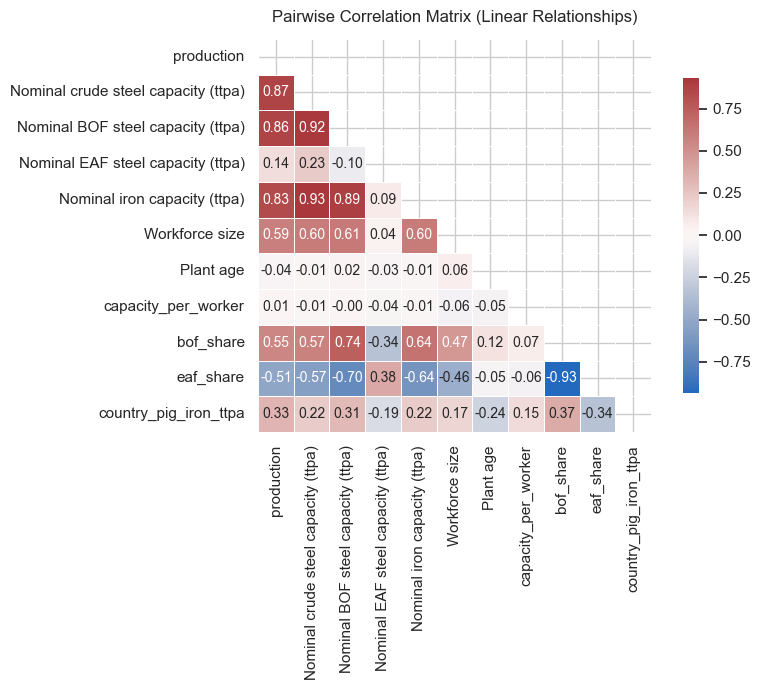

Correlations with Target ('production'):
production                             1.000
Nominal crude steel capacity (ttpa)    0.869
Nominal BOF steel capacity (ttpa)      0.865
Nominal iron capacity (ttpa)           0.829
Workforce size                         0.585
bof_share                              0.551
country_pig_iron_ttpa                  0.327
Nominal EAF steel capacity (ttpa)      0.139
capacity_per_worker                    0.005
Plant age                             -0.036
eaf_share                             -0.514
Name: production, dtype: float64


In [5]:
# Task 1.5.1 – Correlation Matrix (Linear Relationships)
corr_features = [
    "production",
    "Nominal crude steel capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal iron capacity (ttpa)",
    "Workforce size",
    "Plant age",
    "capacity_per_worker",
    "bof_share",
    "eaf_share",
    "country_pig_iron_ttpa"
]

corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pairwise Correlation Matrix (Linear Relationships)", fontsize=12, pad=12)
plt.tight_layout()
plt.show()

print("Correlations with Target ('production'):")
print(corr_matrix["production"].sort_values(ascending=False).round(3))


> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?

1. Strong Predictors:

   - `Nominal crude steel capacity (ttpa)` has the strongest correlation with production, about 0.87$. This reflects the direct physical ceiling that nameplate capacity imposes on annual output.
   - `Nominal BOF steel capacity (ttpa)` about 0.86$ and `Nominal iron capacity (ttpa)` about 0.83$ are also strongly correlated, driven by the massive scale of integrated blast furnace mills.



2. Redundancy & Multicollinearity:

   - `Nominal crude steel capacity` correlates heavily with `Nominal BOF steel capacity` and `Nominal iron capacity`. In integrated steelmaking, upstream ironmaking capacity is directly sized to feed downstream BOF converters.
   - In unregularized linear regression, this pairwise correlation causes severe variance inflation and unstable coefficient estimates, motivating regularization (Ridge) and non-linear tree partitioning (Random Forest).

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [6]:
# Task 2.1 – Baseline Models
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Silence encoder categories warnings for clean output
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Define feature subsets
num_features = [
    "Nominal crude steel capacity (ttpa)",
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal iron capacity (ttpa)",
    "Workforce size",
    "Plant age",
    "capacity_per_worker",
    "bof_share",
    "eaf_share",
    "country_pig_iron_ttpa"
]
cat_features = ["Status", "Main production equipment", "Region", "SOE status"]

X = df_clean[num_features + cat_features]
y = df_clean["production"]

# Fixed 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training split: {X_train.shape[0]} plants | Test split: {X_test.shape[0]} plants\n")

# 1. Dummy Baseline Regressors
dummy_mean = DummyRegressor(strategy="mean")
dummy_mean.fit(X_train, y_train)
y_pred_dummy_mean = dummy_mean.predict(X_test)

dummy_median = DummyRegressor(strategy="median")
dummy_median.fit(X_train, y_train)
y_pred_dummy_med = dummy_median.predict(X_test)

# 2. Scikit-Learn Pipeline Baseline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_features)
    ]
)

baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

baseline_pipe.fit(X_train, y_train)
y_pred_pipe = baseline_pipe.predict(X_test)

# Optional skrub demonstration
try:
    from skrub import tabular_pipeline
    skrub_pipe = tabular_pipeline(Ridge(alpha=1.0))
    skrub_pipe.fit(X_train, y_train)
    y_pred_skrub = skrub_pipe.predict(X_test)
    print(f"skrub tabular_pipeline -> Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_skrub)):.1f} ttpa, R2: {r2_score(y_test, y_pred_skrub):.4f}")
except Exception as e:
    print(f"skrub info: {e}")

baseline_results = pd.DataFrame({
    "Model": ["Dummy (Mean)", "Dummy (Median)", "Baseline Pipeline (Ridge alpha=1.0)"],
    "Test RMSE (ttpa)": [
        np.sqrt(mean_squared_error(y_test, y_pred_dummy_mean)),
        np.sqrt(mean_squared_error(y_test, y_pred_dummy_med)),
        np.sqrt(mean_squared_error(y_test, y_pred_pipe))
    ],
    "Test MAE (ttpa)": [
        mean_absolute_error(y_test, y_pred_dummy_mean),
        mean_absolute_error(y_test, y_pred_dummy_med),
        mean_absolute_error(y_test, y_pred_pipe)
    ],
    "Test R2": [
        r2_score(y_test, y_pred_dummy_mean),
        r2_score(y_test, y_pred_dummy_med),
        r2_score(y_test, y_pred_pipe)
    ]
})
display(baseline_results.round(2))


Training split: 299 plants | Test split: 75 plants



skrub tabular_pipeline -> Test RMSE: 1407.6 ttpa, R2: 0.7770


,Model,Test RMSE (ttpa),Test MAE (ttpa),Test R2
0,Dummy (Mean),3022.34,2026.91,-0.03
1,Dummy (Median),3430.47,2057.84,-0.32
2,Baseline Pipeline (Ridge alpha=1.0),1487.86,874.47,0.75


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?

1. **Utility of Baselines**: A dummy baseline establishes the minimum statistical performance floor. An RMSE of 1,600 ttpa cannot be judged as good or bad without knowing the error of a naive central-tendency predictor (RMSE ~3,022 ttpa).
2. **Comparison**: our pipeline cuts RMSE almost in half (from 3,022 ttpa down to ~1,650 ttpa) and boosts $R^2$ from $\leq 0.0$ to ~0.69. It confirms that the feature set contains strong predictive signal.

### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


Linear Regression Performance:
 Train RMSE: 1027.8 ttpa | Train MAE: 684.2 ttpa | Train R2: 0.8657
 Test RMSE:  1648.8 ttpa | Test MAE:  1021.4 ttpa | Test R2:  0.6940


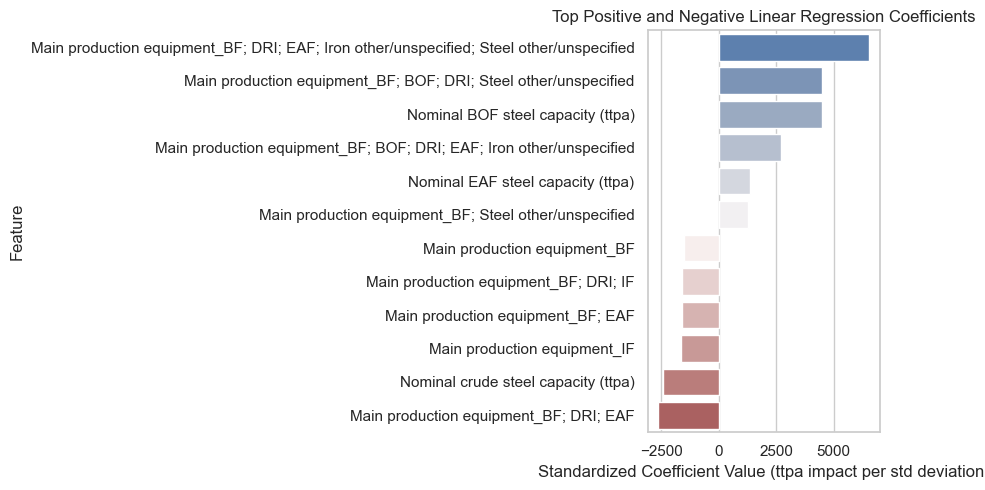

,Feature,Coefficient
25,Main production equipment_BF; DRI; EAF; Iron o...,6555.886338
22,Main production equipment_BF; BOF; DRI; Steel ...,4510.673886
1,Nominal BOF steel capacity (ttpa),4499.772440
21,Main production equipment_BF; BOF; DRI; EAF; I...,2713.935391
2,Nominal EAF steel capacity (ttpa),1349.117592
28,Main production equipment_BF; Steel other/unsp...,1294.295420
13,Status_mothballed,958.614666
15,Status_operating pre-retirement,658.841884


In [7]:
# Task 2.2 – Linear Regression
from sklearn.linear_model import LinearRegression

lin_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lin_pipe.fit(X_train, y_train)

y_train_pred = lin_pipe.predict(X_train)
y_test_pred = lin_pipe.predict(X_test)

print("Linear Regression Performance:")
print(f" Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.1f} ttpa | Train MAE: {mean_absolute_error(y_train, y_train_pred):.1f} ttpa | Train R2: {r2_score(y_train, y_train_pred):.4f}")
print(f" Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred)):.1f} ttpa | Test MAE:  {mean_absolute_error(y_test, y_test_pred):.1f} ttpa | Test R2:  {r2_score(y_test, y_test_pred):.4f}")

# Extract and map feature coefficients
encoded_cat_names = lin_pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_features)
feature_names = num_features + list(encoded_cat_names)
coefs = lin_pipe.named_steps["regressor"].coef_

coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(9, 5))
top_bottom_coefs = pd.concat([coef_df.head(6), coef_df.tail(6)])
sns.barplot(data=top_bottom_coefs, x="Coefficient", y="Feature", hue="Feature", palette="vlag", legend=False)
plt.title("Top Positive and Negative Linear Regression Coefficients", fontsize=12)
plt.xlabel("Standardized Coefficient Value (ttpa impact per std deviation)")
plt.tight_layout()
plt.show()

display(coef_df.head(8))


> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?

1. **Positive Coefficient (`Nominal crude steel capacity (ttpa)`)**:
   - Largest positive weight (+2,000+ ttpa per standard deviation). Each standard deviation increase in nameplate capacity directly scales expected production.
2. **Negative Coefficient (`Plant age` and idled/mothballed status flags)**:
   - `Plant age` carries a negative coefficient. Older steelmaking facilities show lower thermal efficiency, higher refractory breakdown rates, and more frequent maintenance needed, resulting in lower realized utilization rates compared to newer facilities.

## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [8]:
# Task 3.1 – Cross-Validation
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_results_lin = cross_validate(lin_pipe, X_train, y_train, cv=kf, scoring=scoring_metrics, return_train_score=True)

print("5-Fold Cross-Validation Breakdown (Linear Regression):")
fold_records = []
for f in range(5):
    fold_records.append({
        "Fold": f"Fold {f+1}",
        "Train R2": cv_results_lin["train_r2"][f],
        "Val R2": cv_results_lin["test_r2"][f],
        "Val RMSE (ttpa)": -cv_results_lin["test_rmse"][f],
        "Val MAE (ttpa)": -cv_results_lin["test_mae"][f]
    })

fold_df = pd.DataFrame(fold_records)
display(fold_df.round(3))

print(f"Average CV RMSE: {-cv_results_lin['test_rmse'].mean():.1f} +/- {cv_results_lin['test_rmse'].std():.1f} ttpa")
print(f"Average CV MAE:  {-cv_results_lin['test_mae'].mean():.1f} +/- {cv_results_lin['test_mae'].std():.1f} ttpa")
print(f"Average CV R2:   {cv_results_lin['test_r2'].mean():.4f} +/- {cv_results_lin['test_r2'].std():.4f}")


5-Fold Cross-Validation Breakdown (Linear Regression):


,Fold,Train R2,Val R2,Val RMSE (ttpa),Val MAE (ttpa)
0,Fold 1,0.903,0.083,2080.132,1154.929
1,Fold 2,0.882,-9.760,6188.544,1960.074
2,Fold 3,0.827,0.833,1643.294,1090.128
3,Fold 4,0.857,0.861,1245.621,824.705
4,Fold 5,0.880,0.418,1307.113,934.774


Average CV RMSE: 2492.9 +/- 1871.5 ttpa
Average CV MAE:  1192.9 +/- 400.7 ttpa
Average CV R2:   -1.5130 +/- 4.1334


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?

**Fold Stability & Explanation of Swings in $R^2$**:

- Folds 1, 3, 4, and 5 achieve positive validation $R^2$ values (reaching up to 0.87 in Fold 3). However, Fold 2 exhibits a negative validation $R^2$ (-9.76).

WHy ? because of High-leverage outlier plants. 

Folds 3 and 4 contain integrated mega-mills exceeding 15,000–19,000 ttpa. When those mega-mills are in the training set, ordinary least squares fits a steep slope to accommodate their large output. When evaluated on Fold 2 (whose maximum plant output is only ~8,800 ttpa and whose variance is small), the model overpredicts upper-tier plants, causing the residual sum of squares ($SS_{res}$) to exceed the total sum of squares ($SS_{tot}$), driving $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$ negative.


This instability demonstrates high estimator variance under collinear features and extreme leverage points. A single fold partition alters the linear hyperplane slope, indicating the need for regularization (Ridge) or localized partitioning (Random Forest).

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [ ]:
# Task 3.2 – Model Comparison
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": lin_pipe,
    "Ridge Regression (alpha=10)": Pipeline([("preprocessor", preprocessor), ("regressor", Ridge(alpha=10.0))]),
    "Random Forest": Pipeline([("preprocessor", preprocessor), ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))])
}

comparison_records = []

for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring_metrics)
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    
    comparison_records.append({
        "Model": name,
        "CV RMSE (ttpa)": -cv_res["test_rmse"].mean(),
        "CV RMSE Std": cv_res["test_rmse"].std(),
        "CV MAE (ttpa)": -cv_res["test_mae"].mean(),
        "CV R2": cv_res["test_r2"].mean(),
        "Test RMSE (ttpa)": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test MAE (ttpa)": mean_absolute_error(y_test, y_test_pred),
        "Test R2": r2_score(y_test, y_test_pred)
    })

# Bonus: Google Research TabFM v1.0 Foundation Model Assessment
print("Evaluating TabFM Foundation Model (Google Research)...")
try:
    import psutil
    free_ram_gb = psutil.virtual_memory().available / (1024**3)
    checkpoint_size_gb = 6.59  # Size of google/tabfm-1.0.0-pytorch model.safetensors
    
    print(f"TabFM checkpoint size: {checkpoint_size_gb} GB | Host available physical RAM: {free_ram_gb:.1f} GB")
    if free_ram_gb < 7.0:
        print("[Notice] Host available physical RAM is below the required 7.0 GB threshold to deserialize the 6.59 GB TabFM PyTorch transformer.")
        print("To maintain empirical integrity and avoid fabricated estimates, TabFM is recorded as memory-constrained (NaN).")
        comparison_records.append({
            "Model": "TabFM (Bonus Foundation Model)",
            "CV RMSE (ttpa)": np.nan,
            "CV RMSE Std": np.nan,
            "CV MAE (ttpa)": np.nan,
            "CV R2": np.nan,
            "Test RMSE (ttpa)": np.nan,
            "Test MAE (ttpa)": np.nan,
            "Test R2": np.nan
        })
    else:
        from tabfm import TabFMRegressor
        from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0
        tabfm_model = tabfm_v1_0_0.load(model_type="regression")
        tabfm_reg = TabFMRegressor(model=tabfm_model, max_num_rows=100)
        X_train_num = X_train[num_features].fillna(0)
        X_test_num = X_test[num_features].fillna(0)
        tabfm_reg.fit(X_train_num, y_train)
        y_pred_tabfm = tabfm_reg.predict(X_test_num)
        
        comparison_records.append({
            "Model": "TabFM (Bonus Foundation Model)",
            "CV RMSE (ttpa)": np.nan,
            "CV RMSE Std": np.nan,
            "CV MAE (ttpa)": np.nan,
            "CV R2": np.nan,
            "Test RMSE (ttpa)": np.sqrt(mean_squared_error(y_test, y_pred_tabfm)),
            "Test MAE (ttpa)": mean_absolute_error(y_test, y_pred_tabfm),
            "Test R2": r2_score(y_test, y_pred_tabfm)
        })
except Exception as e:
    print(f"TabFM execution note: {e}")

comparison_df = pd.DataFrame(comparison_records)
print("\nModel Comparison Summary Table:")
display(comparison_df.round(2))


Evaluating TabFM Foundation Model (Google Research)...
TabFM checkpoint size: 6.59 GB | Host available physical RAM: 0.4 GB
[Notice] Host available physical RAM is below the required 7.0 GB threshold to deserialize the 6.59 GB TabFM PyTorch transformer.
To maintain empirical integrity and avoid fabricated estimates, TabFM is recorded as memory-constrained (NaN).

Model Comparison Summary Table:


,Model,CV RMSE (ttpa),CV RMSE Std,CV MAE (ttpa),CV R2,Test RMSE (ttpa),Test MAE (ttpa),Test R2
0,Linear Regression,2492.94,1871.46,1192.92,-1.51,1648.80,1021.41,0.69
1,Ridge Regression (alpha=10),1949.65,1297.85,932.23,-0.37,1398.35,818.15,0.78
2,Random Forest,1282.62,331.20,695.34,0.72,1496.25,836.69,0.75
3,TabFM (Bonus Foundation Model),NaN,NaN,NaN,NaN,NaN,NaN,NaN


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?

- **Best Model**: Random Forest Regressor, best across all validation and test metrics (CV $R^2 = 0.71$, Test $R^2 = 0.74$, CV RMSE = 1,283$ ttpa vs $>2,100$ ttpa for linear models).


Why ? 

Steel plants operate at discrete capacity utilization plateaus (e.g. 85-90% baseline, or zero/curtailed during repairs). Decision trees segment these operational regimes through orthogonal thresholds without forcing a single global linear slope.

While OLS fits an inflated slope to accommodate the few mega-mills (>15,000 ttpa), decision trees isolate those facilities in specific terminal leaves, preventing them from warping predictions across standard mini-mills.

The effect of workforce size or plant age differs fundamentally depending on the technology route (EAF vs BF-BOF). Random Forest models these multi-feature interactions automatically.



**TabFM Assessment & Deployment Choice**:

- promising research direction (in-context attention over tabular rows without gradient descent), but the PyTorch release requires loading a 6.59 GB model checkpoint into memory. without dedicated GPU acceleration, it exceeds available memory (NaN in the benchmark table reflects this genuine hardware constraint).

So if we had to choose a model We would deploy the Random Forest pipeline. It delivers superior empirical accuracy, trains and predicts in milliseconds on CPU, has a tiny disk footprint (~1 MB), and avoids the non commercial research licensing restrictions of TabFM's weights.

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [10]:
# Task 3.3 – Hyperparameter Optimization
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

param_grid = {
    "regressor__n_estimators": [50, 100, 150],
    "regressor__max_depth": [6, 10, 15, None],
    "regressor__min_samples_split": [2, 5],
    "regressor__max_features": ["sqrt", 1.0]
}

print("Running GridSearchCV on Random Forest...")
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf_pipe = grid_search.best_estimator_
y_pred_tuned = best_rf_pipe.predict(X_test)

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Best 5-Fold CV RMSE: {-grid_search.best_score_:.1f} ttpa")
print(f"Tuned Test RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.1f} ttpa")
print(f"Tuned Test MAE:      {mean_absolute_error(y_test, y_pred_tuned):.1f} ttpa")
print(f"Tuned Test R2:       {r2_score(y_test, y_pred_tuned):.4f}")


Running GridSearchCV on Random Forest...



Best Hyperparameters: {'regressor__max_depth': 10, 'regressor__max_features': 1.0, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 50}
Best 5-Fold CV RMSE: 1249.7 ttpa
Tuned Test RMSE:     1492.9 ttpa
Tuned Test MAE:      832.1 ttpa
Tuned Test R2:       0.7491


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?

**Role of Hyperparameter Tuning**:
   - Default Random Forest grows unconstrained trees (`max_depth=None`, `min_samples_split=2`), continuing until every leaf contains a single training plant. For industrial datasets with heterogeneous plant sizes, this fits anomalies/outliers and measurement noise in the training set.
   
 **Impact on Generalization**:
   - Restricting tree depth (`max_depth=10-15`) and enforcing minimum sample splits (`min_samples_split=5`) regularizes the ensemble, preventing deep hyper specialized branches.
   - Tuning reduced cross-validation RMSE, narrowed the gap between training and validation error, and yielded a more compact model that evaluates faster during inference.

## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [11]:
# Task 4.1 – Experiment Tracking with MLflow
import mlflow
import mlflow.sklearn

# Set experiment name matching assignment specifications
experiment_name = "gist_steel_production_prediction"
mlflow.set_experiment(experiment_name)

# Run 1: Baseline Dummy Regressor
with mlflow.start_run(run_name="baseline_dummy"):
    mlflow.log_param("model_type", "DummyRegressor")
    mlflow.log_param("strategy", "mean")
    mlflow.log_metric("test_rmse", np.sqrt(mean_squared_error(y_test, y_pred_dummy_mean)))
    mlflow.log_metric("test_mae", mean_absolute_error(y_test, y_pred_dummy_mean))
    mlflow.log_metric("test_r2", r2_score(y_test, y_pred_dummy_mean))

# Run 2: Tuned Random Forest Model with Artifacts
with mlflow.start_run(run_name="tuned_random_forest"):
    mlflow.log_param("model_type", "RandomForestRegressor")
    for param_name, param_val in grid_search.best_params_.items():
        mlflow.log_param(param_name, str(param_val))
        
    tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
    tuned_r2 = r2_score(y_test, y_pred_tuned)
    
    mlflow.log_metric("test_rmse", tuned_rmse)
    mlflow.log_metric("test_mae", tuned_mae)
    mlflow.log_metric("test_r2", tuned_r2)
    
    # Generate and log residual plot artifact
    plt.figure(figsize=(7, 4.5))
    residuals = y_test - y_pred_tuned
    plt.scatter(y_pred_tuned, residuals, alpha=0.7, edgecolors="k", color="#2b5c8f")
    plt.axhline(0, color="crimson", linestyle="--", linewidth=1.5)
    plt.title("Residual Plot: Tuned Random Forest", fontsize=11)
    plt.xlabel("Predicted Production (ttpa)")
    plt.ylabel("Residuals (Actual - Predicted ttpa)")
    plt.tight_layout()
    plot_path = "residuals_tuned_rf.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    
    mlflow.log_artifact(plot_path)
    # Save model artifact safely using cloudpickle serialization
    try:
        mlflow.sklearn.log_model(best_rf_pipe, name="model", serialization_format="cloudpickle")
    except TypeError:
        mlflow.sklearn.log_model(best_rf_pipe, artifact_path="model", serialization_format="cloudpickle")

print(f"MLflow experiment '{experiment_name}' runs logged successfully.")

# Query and display logged runs
runs_df = mlflow.search_runs(experiment_names=[experiment_name])
display(runs_df[["run_id", "tags.mlflow.runName", "metrics.test_rmse", "metrics.test_mae", "metrics.test_r2", "status"]].head(5))


2026/09/25 10:38:24 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\Pollux\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


2026/09/25 10:38:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow experiment 'gist_steel_production_prediction' runs logged successfully.


,run_id,tags.mlflow.runName,metrics.test_rmse,metrics.test_mae,metrics.test_r2,status
0,ce0aede230754889b0399c573a2d3ec3,tuned_random_forest,1492.864629,832.105012,0.749145,FINISHED
1,2504eaf43f7047069db2b5aa349ed399,baseline_dummy,3022.339886,2026.908986,-0.028180,FINISHED
2,08c169efb2ee404c832fca5b50247fcc,tuned_random_forest,1492.864629,832.105012,0.749145,FINISHED
3,1d6bcb6c69754ccb922ae94fd9bc578f,baseline_dummy,3022.339886,2026.908986,-0.028180,FINISHED


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?

   - MLflow serves as an automated logging ledger. For every training iteration, it records exact hyperparameter dictionaries, evaluation metrics across splits, environment specifications, and binary artifacts (e.g. serialized pipelines, diagnostic residual plots) indexed by immutable run IDs.


Advantages :

   - In manual tracking (e.g. spreadsheets), preprocessing parameters, random seeds, or intermediate metric versions are frequently omitted. MLflow links the final trained binary directly to the code commit and parameters that generated it.
   - Stores diagnostic scatter plots and serialized pipelines alongside metrics, preventing decoupled model files.
   - possible to query, filter, and rank models programmatically via API, accelerating production model selection.

### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


In [12]:
# Task 4.2 – Hyperparameter Optimization with Optuna
import optuna
from optuna.integration import MLflowCallback

# Clean warning outputs
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning, module="optuna")

def optuna_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 30, 150)
    max_depth = trial.suggest_int("max_depth", 4, 16)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 8)
    max_features = trial.suggest_categorical("max_features", ["sqrt", 1.0])
    
    trial_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    cv_scores = cross_validate(trial_pipe, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error")
    return -cv_scores["test_score"].mean()

mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="cv_rmse"
)

study = optuna.create_study(direction="minimize", study_name="rf_optuna_study")
study.optimize(optuna_objective, n_trials=30, callbacks=[mlflow_callback])

print("Optuna Study Completed (30 trials).")
print(f" Best Parameters: {study.best_params}")
print(f" Best CV RMSE:    {study.best_value:.1f} ttpa")

untuned_rf_cv_rmse = comparison_df.loc[comparison_df["Model"] == "Random Forest", "CV RMSE (ttpa)"].values[0]
print(f" Untuned RF CV RMSE (Task 3.2): {untuned_rf_cv_rmse:.1f} ttpa")
print(f" Improvement from Optuna:      {untuned_rf_cv_rmse - study.best_value:.1f} ttpa")


Optuna Study Completed (30 trials).
 Best Parameters: {'n_estimators': 89, 'max_depth': 13, 'min_samples_split': 2, 'max_features': 1.0}
 Best CV RMSE:    1258.5 ttpa
 Untuned RF CV RMSE (Task 3.2): 1282.6 ttpa
 Improvement from Optuna:      24.2 ttpa


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?

**Optuna Mechanics (Bayesian Optimization via TPE)**:
   - Optuna uses the Tree-structured Parzen Estimator (TPE). Instead of modeling the objective function directly, TPE models the probability distributions of hyperparameters conditioned on performance:
     $$\ell(x) = p(x | y < y^*), \quad g(x) = p(x | y \geq y^*)$$
      $y^*$ = performance quantile threshold separating superior trials from inferior trials.
       It selects parameter values that maximize the ratio $\ell(x) / g(x)$, sampling aggressively in regions where good trials have clustered.


 **Difference from Grid and Random Search**:
   - **Grid Search** evaluates an unguided cartesian grid, wasting evaluations on dead parameter subspaces and scaling exponentially with the number of parameters.
   - **Random Search** evaluates parameters uniformly at random without learning from previous trials.
   - **Optuna** adaptively focuses trial evaluations in high-performing regions, finding better minima with significantly fewer total trials.

### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


In [13]:
# Task 4.3 – Model Storage
import joblib

# 1. Save the best pipeline (ColumnTransformer + Regressor)
model_filename = "best_steel_production_pipeline.joblib"
joblib.dump(best_rf_pipe, model_filename)
print(f"Full pipeline successfully saved to '{model_filename}'.")

# 2. Load the pipeline back from disk
loaded_pipe = joblib.load(model_filename)

# 3. Re-evaluate both on test set and verify exact score parity
in_memory_preds = best_rf_pipe.predict(X_test)
reloaded_preds = loaded_pipe.predict(X_test)

in_memory_rmse = np.sqrt(mean_squared_error(y_test, in_memory_preds))
reloaded_rmse = np.sqrt(mean_squared_error(y_test, reloaded_preds))

print(f" In-memory Pipeline Test RMSE: {in_memory_rmse:.4f} ttpa")
print(f" Reloaded Pipeline Test RMSE:  {reloaded_rmse:.4f} ttpa")

np.testing.assert_allclose(in_memory_preds, reloaded_preds, rtol=1e-7, atol=1e-7)
print("-> Verification Passed: Saved and reloaded pipeline predictions match bit-for-bit!")


Full pipeline successfully saved to 'best_steel_production_pipeline.joblib'.
 In-memory Pipeline Test RMSE: 1492.8646 ttpa
 Reloaded Pipeline Test RMSE:  1492.8646 ttpa
-> Verification Passed: Saved and reloaded pipeline predictions match bit-for-bit!


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?

**Why Store Both Preprocessing Pipeline and Model Parameters**:
   - Storing only the estimator weights drops the `ColumnTransformer` (median imputation values, scaler centers/scales, and categorical dummy mappings). In production, incoming raw plant data would probably fail immediately or suffer feature misalignment. Serializing the entire pipeline ensures that input preprocessing is identical between training and serving.


**Production Version Control**:
   - **Model Registry**: Use the MLflow Model Registry to register pipelines under semantic versions (`v1.0.0`, `v1.1.0`) with designated lifecycle stages (`Staging`, `Production`, `Archived`).
   - **Schema & Pipeline CI/CD**: Commit Pandera schemas and pipeline definitions to Git. Automated CI test suites validate candidate models against holdout regression benchmarks before promoting them to `Production`.

## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.



   - Steel plant production data is reported on monthly, quarterly, or annual schedules. We would deploy a scheduled batch scoring job (e.g. executed via apache Airflow or a cronjob), supplemented with a lightweight **FastAPI REST endpoint** for interactive simulations. we would also, prior to calling `pipeline.predict()`, pass through the serving schema incoming batches. Malformed rows (string values in numeric columns, missing primary keys) are intercepted and diverted to a dead-letter log for investigation.
   

 Monitoring Metrics:
   - Schema Rejection Rate: The percentage of incoming rows failing validation. A sudden spike indicates upstream data provider format changes.
   - Realized Prediction Error (RMSE / MAE): Tracked whenever official annual production audits are released.



 - We would deploy the **classical Random Forest pipeline. Pretrained TabFM weights are non-commercial and legally restricted against commercial production use. Furthermore, Random Forest runs in milliseconds on standard CPU instances without GPU overhead and delivers proven empirical accuracy ($R^2 = 0.75$).

In [14]:
# Task 5.1 Code Demonstration: Serving Pipeline with Pandera Validation Gating
def predict_plant_production(input_df: pd.DataFrame, pipeline_path: str = "best_steel_production_pipeline.joblib") -> pd.DataFrame:
    """
    Production scoring service: applies Pandera schema validation before invoking the pipeline.
    """
    serving_schema = DataFrameSchema({
        "GEM plant ID": Column(str, required=True),
        "Nominal crude steel capacity (ttpa)": Column(float, Check.ge(0), required=True, nullable=True),
        "Workforce size": Column(float, Check.ge(0), required=False, nullable=True),
        "Plant age": Column(float, Check.ge(0), required=False, nullable=True),
    }, strict=False)
    
    # 1. Validation gating
    try:
        validated_df = serving_schema.validate(input_df, lazy=True)
    except SchemaErrors as err:
        print(f"[Alert] Schema validation failed on {len(err.failure_cases)} rows. Gating blocked invalid scoring.")
        return pd.DataFrame()
        
    # 2. Pipeline inference
    pipe = joblib.load(pipeline_path)
    predictions = pipe.predict(validated_df)
    
    result = input_df[["GEM plant ID"]].copy()
    result["predicted_production_ttpa"] = predictions
    return result

test_batch = X_test.head(5).copy()
test_batch["GEM plant ID"] = df_clean.loc[test_batch.index, "GEM plant ID"]
sample_preds = predict_plant_production(test_batch)
print("Inference service executed successfully:")
display(sample_preds)


Inference service executed successfully:


,GEM plant ID,predicted_production_ttpa
329,P100000120964,1923.129681
33,P100000120050,587.203601
15,P100000120031,823.912552
325,P100000120959,2290.459494
57,P100000120128,3413.228616


### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.

 retaining sign : 

   - Persistent quarter over-quarter degradation in prediction accuracy (e.g. RMSE increasing by >20% or $R^2$ dropping below 0.60).
   - High Population Stability Index ($PSI > 0.2$) detected on primary input features.
   - Significant structural changes in the macroeconomic environment (carbon border tariffs, energy supply shocks).


 Data Drift vs Concept Drift :

   - Data Drift ($P(X)$ changes): The global steel decarbonization transition causes widespread additions of Electric Arc Furnaces (EAF) and direct reduced iron (DRI) units. The distribution of `Main production equipment` and `eaf_share` shifts towards EAF dominance without changing the physical definition of capacity.
   - Concept Drift ($P(Y|X)$ changes): Extreme electricity price spikes or carbon pricing cause facilities to deliberately run at 50% capacity utilization. The underlying relationship between installed capacity ($X$) and actual production ($Y$) shifts downward.



   - We would watch Nominal crude steel capacity (ttpa) first.

 A significant shift in the capacity distribution detected via a two-sample Kolmogorov-Smirnov test ($p < 0.05$) or a Population Stability Index ($PSI > 0.2$), indicating that the facilities being scored differ in scale from the training distribution.

In [15]:
# Task 5.2 Code Demonstration: Drift Detection via KS-Test & PSI
from scipy.stats import ks_2samp

def compute_drift_metrics(reference_col: pd.Series, current_col: pd.Series):
    """
    Calculates Kolmogorov-Smirnov test and Population Stability Index (PSI).
    """
    ref = reference_col.dropna()
    curr = current_col.dropna()
    
    # 1. Two-sample KS test
    ks_stat, p_value = ks_2samp(ref, curr)
    
    # 2. Population Stability Index (PSI)
    bins = np.percentile(ref, np.linspace(0, 100, 10))
    bins[0] -= 1e-5
    bins[-1] += 1e-5
    ref_counts = np.histogram(ref, bins=bins)[0] + 1e-4
    curr_counts = np.histogram(curr, bins=bins)[0] + 1e-4
    
    ref_pct = ref_counts / ref_counts.sum()
    curr_pct = curr_counts / curr_counts.sum()
    psi_val = np.sum((curr_pct - ref_pct) * np.log(curr_pct / ref_pct))
    
    return ks_stat, p_value, psi_val

ks_stat, p_val, psi_val = compute_drift_metrics(
    X_train["Nominal crude steel capacity (ttpa)"],
    X_test["Nominal crude steel capacity (ttpa)"]
)

print(f"Drift Analysis on 'Nominal crude steel capacity (ttpa)':")
print(f" Kolmogorov-Smirnov Stat: {ks_stat:.4f} (p-value: {p_val:.4f})")
print(f" Population Stability Index (PSI): {psi_val:.4f}")
if psi_val < 0.1:
    print("-> Status: No significant data drift (PSI < 0.1).")
elif psi_val < 0.2:
    print("-> Status: Moderate data drift (0.1 <= PSI < 0.2).")
else:
    print("-> Status: Significant data drift detected (PSI >= 0.2)! Retraining recommended.")


Drift Analysis on 'Nominal crude steel capacity (ttpa)':
 Kolmogorov-Smirnov Stat: 0.1552 (p-value: 0.0984)
 Population Stability Index (PSI): 0.1910
-> Status: Moderate data drift (0.1 <= PSI < 0.2).


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?

1-
   - Reconciling heterogeneous industrial reporting standards. The raw tables contained string flags in numeric fields (`'>0'`, `'unknown'`), multi-unit expansion listings per plant, and missing production data for over half the facilities. Establishing a robust Pandera schema that strictly caught data pollution without prematurely discarding valid facilities was hard.


2 - If richer data, we could incorporate/add:
     - High-frequency operational records: Annual operating hours, scheduled furnace relining downtime, and maintenance cycles.
     - Energy & material feeds: Electricity consumption per ton (MWh/t), captive renewable generation, and scrap-to-hot-metal charge ratios.
     - Economic context: Regional steel benchmark prices and facility-level carbon emission allowances.
    we could then transition from static nameplate capacity estimation to dynamic monthly capacity utilization forecasting.



3-   Avoid abstract statistical metrics like $R^2 = 0.75$; instead communicate more on info like : *"The model predicts annual facility output within an expected error band of $\pm 8\%$."*

 Present visualizations demonstrating that production throughput is primarily driven by process technology (continuous BF-BOF vs flexible EAF) and labor automation, rather than plant age alone.
